In [ ]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="BYeHkeZIrf9VaHXpKp3Y")
project = rf.workspace("imit-h5ows").project("soil-detection-l0ngo")
version = project.version(3)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 19.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Soil-detection-3 in yolov8:: 100%|██████████| 582/582 [00:00<00:00, 1430.60it/s]


In [ ]:
import os
import cv2
import shutil
import numpy as np
from PIL import Image
from tqdm import tqdm
import albumentations as A
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


#Paths

DATASET_ROOT = "/content/Soil-detection-3"   # main folder from Roboflow

TRAIN_IMG = os.path.join(DATASET_ROOT, "train/images")
TRAIN_LBL = os.path.join(DATASET_ROOT, "train/labels")

TEST_IMG = os.path.join(DATASET_ROOT, "test/images")
TEST_LBL = os.path.join(DATASET_ROOT, "test/labels")

OUTPUT = "/content/processed"

AUGMENTED_DIR = os.path.join(OUTPUT, "augmented")
ENCODING_DIR = os.path.join(OUTPUT, "encodings")

TRAIN_OUT_IMG = os.path.join(OUTPUT, "train/images")
TRAIN_OUT_LBL = os.path.join(OUTPUT, "train/labels")

TEST_OUT_IMG = os.path.join(OUTPUT, "test/images")
TEST_OUT_LBL = os.path.join(OUTPUT, "test/labels")

os.makedirs(AUGMENTED_DIR, exist_ok=True)
os.makedirs(ENCODING_DIR, exist_ok=True)
os.makedirs(TRAIN_OUT_IMG, exist_ok=True)
os.makedirs(TRAIN_OUT_LBL, exist_ok=True)
os.makedirs(TEST_OUT_IMG, exist_ok=True)
os.makedirs(TEST_OUT_LBL, exist_ok=True)

print("Folders created successfully!")


#Copy Train/Test images + labels

def copy_folder(src, dst):
    for f in tqdm(os.listdir(src), desc=f"Copying {src}"):
        src_fp = os.path.join(src, f)
        dst_fp = os.path.join(dst, f)
        shutil.copy(src_fp, dst_fp)

copy_folder(TRAIN_IMG, TRAIN_OUT_IMG)
copy_folder(TRAIN_LBL, TRAIN_OUT_LBL)
copy_folder(TEST_IMG, TEST_OUT_IMG)
copy_folder(TEST_LBL, TEST_OUT_LBL)

print("\nTrain & Test copied to processed folder!")


#Augmentation Pipeline

augmentor = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.GaussianBlur(p=0.3),
])


#Apply Augmentation (only on train images)

def augment_images():
    images = os.listdir(TRAIN_IMG)

    for img_name in tqdm(images, desc="Augmenting training images"):
        img_path = os.path.join(TRAIN_IMG, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = augmentor(image=img_rgb)["image"]

        save_path = os.path.join(AUGMENTED_DIR, img_name)
        cv2.imwrite(save_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

    print("Augmentation complete!")



# Encoding using MobileNetV2

encoder = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")

def encode_images():
    images = os.listdir(AUGMENTED_DIR)

    for img_name in tqdm(images, desc="Encoding images"):
        img_path = os.path.join(AUGMENTED_DIR, img_name)

        img = Image.open(img_path).convert("RGB").resize((224, 224))
        img_array = preprocess_input(np.array(img))
        img_array = np.expand_dims(img_array, axis=0)

        embedding = encoder.predict(img_array)

        save_path = os.path.join(ENCODING_DIR, img_name.replace(".jpg", ".npy"))
        np.save(save_path, embedding)

    print(" Image embeddings created!")


#Execute Full Pipeline
augment_images()
encode_images()

#Verification

print("\nFinal Summary:")
print("Training images:", len(os.listdir(TRAIN_OUT_IMG)))
print("Testing images:", len(os.listdir(TEST_OUT_IMG)))
print("Augmented images:", len(os.listdir(AUGMENTED_DIR)))
print("Encodings:", len(os.listdir(ENCODING_DIR)))


Folders created successfully!


Copying /content/Soil-detection-3/test/labels: 100%|██████████| 28/28 [00:00<00:00, 5521.93it/s]


✅ Train & Test copied to processed folder!



`input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
Augmenting training images: 100%|██████████| 199/199 [00:03<00:00, 50.85it/s]


✅ Augmentation complete!


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


Encoding images:  99%|█████████▉| 198/199 [00:55<00:00,  6.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


Encoding images: 100%|██████████| 199/199 [00:55<00:00,  3.55it/s]

✅ Image embeddings created!

Final Summary:
Training images: 199
Testing images: 28
Augmented images: 199
Encodings: 199


In [ ]:
import os

print("DATASET ROOT:", os.listdir("/content"))
print("Soil-detection-3:", os.listdir("/content/Soil-detection-3"))
print("train:", os.listdir("/content/Soil-detection-3/train"))
print("train/images:", os.listdir("/content/Soil-detection-3/train/images")[:10])


DATASET ROOT: ['.config', 'processed', 'Soil-detection-3', 'sample_data']
Soil-detection-3: ['data.yaml', 'train', 'valid', 'test', 'README.dataset.txt', 'README.roboflow.txt']
train: ['labels', 'images']
train/images: ['Copy-of-images267-1-_jpg.rf.273eb8fa2592f17602cef830fb6bcdf4.jpg', 'Copy-of-image2_jpeg.rf.ec20e2b9623dcbcc82d9f6a258869ab8.jpg', 'OIP-g1CkewGUpICmIzp9SBuyTAHaGz_jpg.rf.7bccd941d1a7537acb07a8f4babe8adc.jpg', 'black-earth-background-natural-soil-260nw-2068346966_jpg.rf.cd9a7b7a37993ff7855b4e29575ab5f4.jpg', 'ground-texture-top-view-dark-260nw-399028210_jpg.rf.af04834d937e694b6b3735f794834f1c.jpg', 'Red_31_jpg.rf.e5f0f5a053953e706261d26d593e6734.jpg', 'images363_jpg.rf.f273b2974ee6c100738d3d5471a1c102.jpg', 'OIP-ZefJmtET3Dfl4AJkIZVRfwHaE8_jpg.rf.1b7c1fd0b0b19b68d2da051b8f7d1098.jpg', 'Red_17_jpg.rf.1c245fe392c520daae5869cd025de322.jpg', 'images371_jpg.rf.0d8812af0d07482cb4422ba57878371e.jpg']


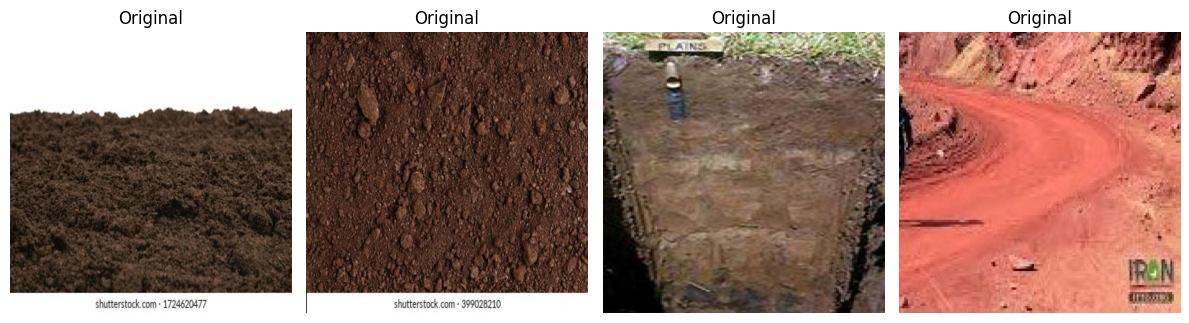

In [ ]:
import matplotlib.pyplot as plt
import random
import os
import cv2


# Paths

ORIGINAL = TRAIN_OUT_IMG          # processed/train/images
AUGMENTED = AUGMENTED_DIR         # processed/augmented

#Function to display random samples

def show_samples():
    orig_imgs = os.listdir(ORIGINAL)
    aug_imgs = os.listdir(AUGMENTED)

    # Select random 4 images from each
    sample_orig = random.sample(orig_imgs, 4)
    sample_aug = random.sample(aug_imgs, 4)

    plt.figure(figsize=(12, 8))

    # ---- Plot original images ----
    for i, img_name in enumerate(sample_orig):
        img_path = os.path.join(ORIGINAL, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

    '''# ---- Plot augmented images ----
    for i, img_name in enumerate(sample_aug):
        img_path = os.path.join(AUGMENTED, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i + 5)
        plt.imshow(img)
        plt.title("Augmented")
        plt.axis("off")'''

    plt.tight_layout()
    plt.show()

# Run function
show_samples()


In [ ]:
import os

TEST_IMG = "/content/processed/test/images"
print(os.listdir(TEST_IMG)[:10])


['Copy-of-clay-soil-cropped_jpg.rf.9dfcef24065c2fa79a282f89bff22b80.jpg', 'Black_38_jpg.rf.cce2afe5e739cb1d77fbdfd7d51d5012.jpg', 'closeup-black-color-soil-texture-260nw-570892720_jpg.rf.a63db07d023f79d6c7c0a4afac5e5c5e.jpg', 'vertical-texture-red-dry-clay-260nw-95698423_jpg.rf.84b5a11a0df3b6a6218f7db86afb31d6.jpg', 'OIP-DYv2HhVuCZkJuo6K4NcjgwHaE6_jpg.rf.a8bb88577cd95755f1a788edae3fdcaf.jpg', 'dried-cracked-earth-soil-ground-260nw-519337915_jpg.rf.d14cad1c7ef3738d4e1a4a586f7e3e81.jpg', 'Copy-of-images391_jpg.rf.d6806cb6a184655da8cdd3a57cfcd371.jpg', 'closeup-plowed-field-fertile-black-260nw-1831062274_jpg.rf.78ff99b9a89318760278d18356165383.jpg', 'Clay_47_jpg.rf.75ea8b632fb8f5e1a540b31945d9ff4d.jpg', 'brown-soil-texture-background-cultivated-260nw-1898667757_jpg.rf.5acd27a74577427cfe6208a238b19114.jpg']


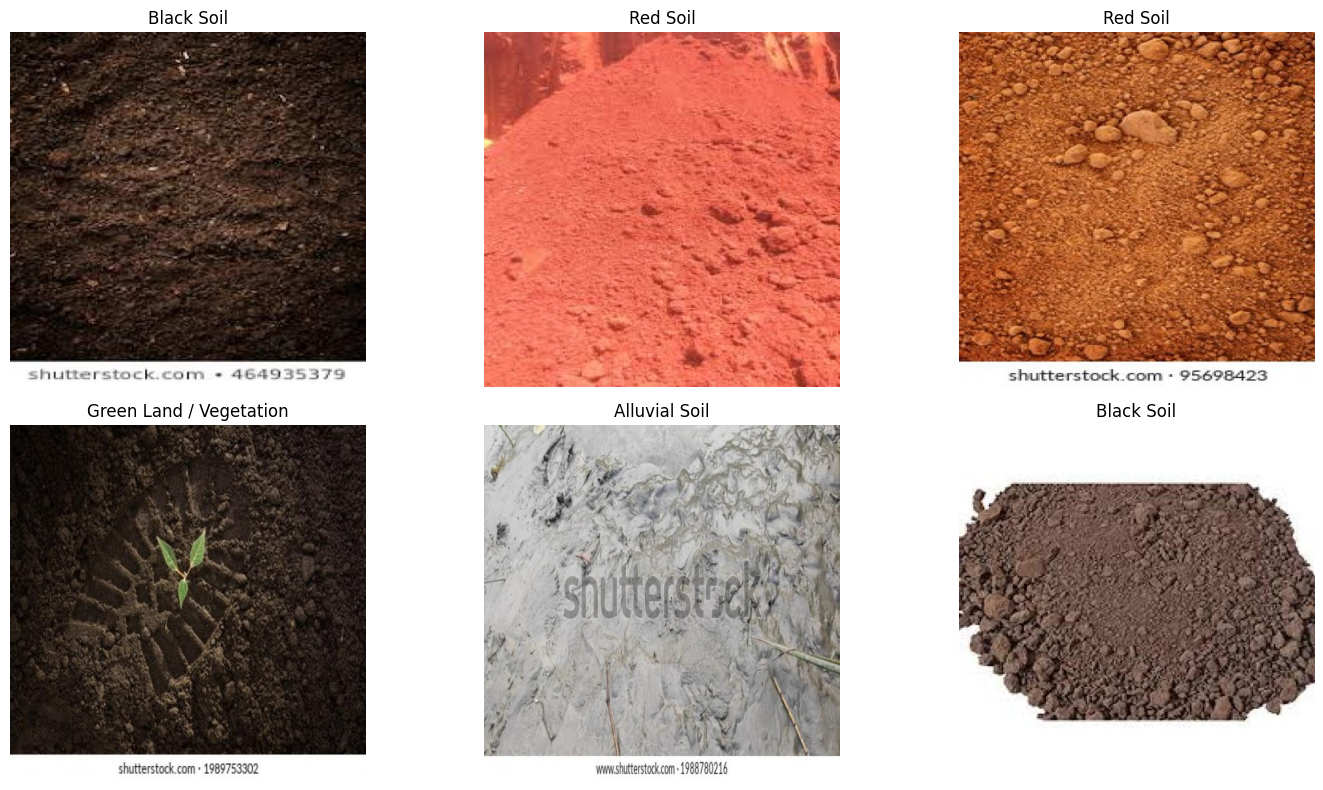

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2

# Path to test images
TEST_IMG = "/content/processed/test/images"

# Pick 6 random test images (or fewer if folder small)
sample_images = [
    'Black_38_jpg.rf.cce2afe5e739cb1d77fbdfd7d51d5012.jpg',
    'Red_44_jpg.rf.166b249f96dfcba4e9996f754ed4ecaf.jpg',
    'vertical-texture-red-dry-clay-260nw-95698423_jpg.rf.84b5a11a0df3b6a6218f7db86afb31d6.jpg',
    'footprint-on-ground-soil-green-260nw-1989753302_jpg.rf.471b75f9a457fe6b2b930f03a526681c.jpg',
    'alluvial-soil-geographical-study-reference-600w-1988780216_jpg.rf.212572abc4ca1273ec29a6529edd8e83.jpg',
    'Black_44_jpg.rf.bfb078e5b0304edb36b2cc1d57ea3cbc.jpg'
]

# Map filenames to soil/land names
def soil_name(filename):
    filename = filename.lower()
    if "black" in filename:
        return "Black Soil"
    elif "red" in filename:
        return "Red Soil"
    elif "alluvial" in filename:
        return "Alluvial Soil"
    elif "green" in filename or "vegetation" in filename:
        return "Green Land / Vegetation"
    elif "clay" in filename:
        return "Red Clay Soil"
    else:
        return "Unknown"

# Plot images
plt.figure(figsize=(15, 8))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(TEST_IMG, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(soil_name(img_name))
    plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")
metrics = model.val()  # evaluate model


precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']
map50 = metrics.results_dict['metrics/mAP50(B)']
map5095 = metrics.results_dict['metrics/mAP50-95(B)']

# Calculate simple accuracy
accuracy = (precision + recall) / 2

# Print results
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("mAP50:", round(map50, 4))
print("mAP50-95:", round(map5095, 4))
print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")


Ultralytics 8.3.236 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1850.9±704.3 MB/s, size: 78.4 KB)
val: Scanning /content/processed/test/labels.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 40.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.7s/it 7.4s
                   all         28         33      0.877      0.826      0.912      0.615
            Black Soil          9         11      0.953      0.636      0.901      0.532
              Red Soil          8          9      0.897          1      0.951      0.636
         Red Clay Soil          4          4      0.851          1      0.995      0.796
         Alluvial Soil          7          9      0.806      0.667      0.801      0.495
Speed: 8.3ms preprocess, 236.2ms inference, 0.0ms 

In [ ]:
import os
label_dir = "/content/processed/train/labels"
count = {}
for filename in os.listdir(label_dir):
    path = os.path.join(label_dir, filename)
    with open(path, "r") as f:
        cls = int(f.readline().split()[0])
        count[cls] = count.get(cls, 0) + 1
print("Training images per class:", count)

Training images per class: {1: 55, 0: 64, 2: 29, 3: 51}



image 1/1 /content/Soil-detection-3/test/images/soil-upper-layer-earth-which-600w-1857677119_jpg.rf.5f603136d0837aac5e26e4f5efd312e4.jpg: 512x512 1 Black Soil, 572.6ms
Speed: 8.5ms preprocess, 572.6ms inference, 12.3ms postprocess per image at shape (1, 3, 512, 512)


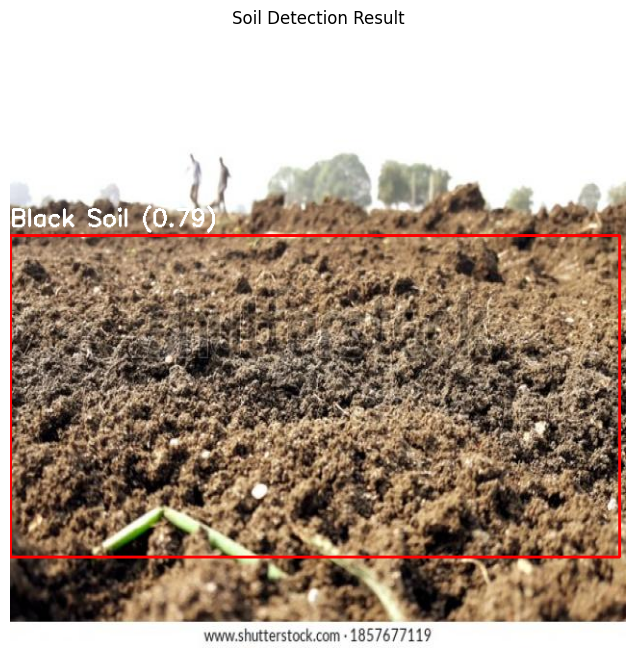

Predicted Soil Type: Black Soil
Confidence: 0.7871029376983643


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load YOLO soil detection model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Input image path
img_path = "/content/Soil-detection-3/test/images/soil-upper-layer-earth-which-600w-1857677119_jpg.rf.5f603136d0837aac5e26e4f5efd312e4.jpg"

# Run prediction
results = model.predict(img_path)[0]

# Read and convert the image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
display_img = img.copy()

soil_name = "Unknown"
confidence = 0.0

# Draw detected boxes
if results.boxes is not None:
    for box in results.boxes:
        # Extract coordinates
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0])
        confidence = float(box.conf[0])
        soil_name = results.names[cls_id]

        # Draw rectangle
        cv2.rectangle(display_img, (int(x1), int(y1)), (int(x2), int(y2)),
                      (255, 0, 0), 2)

        # Add soil label
        label = f"{soil_name} ({confidence:.2f})"
        cv2.putText(display_img, label, (int(x1), int(y1) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

# Show annotated image
plt.figure(figsize=(10, 8))
plt.imshow(display_img)
plt.axis("off")
plt.title("Soil Detection Result")
plt.show()

print("Predicted Soil Type:", soil_name)
print("Confidence:", confidence)


In [ ]:
from ultralytics import YOLO

# Load your trained soil detection model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Print class names
print("Classes in the model:")
for cls_id, name in model.names.items():
    print(cls_id, ":", name)

print("\nTotal number of classes:", len(model.names))


Classes in the model:
0 : Black Soil
1 : Red Soil
2 : Red Clay Soil
3 : Alluvial Soil
4 : Green Land

Total number of classes: 5



image 1/1 /content/redddd.jpeg: 384x512 1 Red Soil, 177.5ms
Speed: 3.6ms preprocess, 177.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 512)


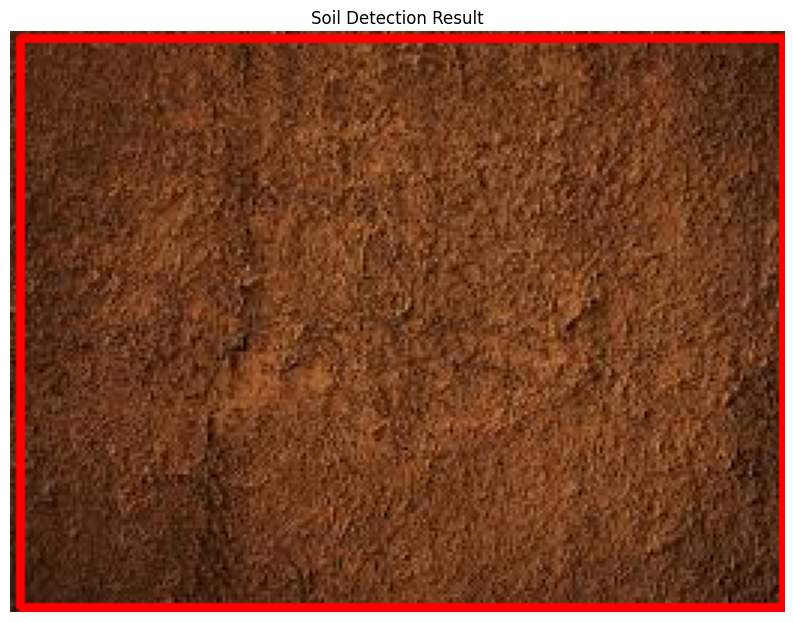

Predicted Soil Type: Red Soil
Confidence: 0.6654879450798035


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load YOLO soil detection model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Input image path
img_path = "/content/redddd.jpeg"
# Run prediction
results = model.predict(img_path)[0]

# Read and convert the image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
display_img = img.copy()


# Draw detected boxes
if results.boxes is not None:
    for box in results.boxes:
        # Extract coordinates
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0])
        confidence = float(box.conf[0])
        soil_name = results.names[cls_id]

        # Draw rectangle
        cv2.rectangle(display_img, (int(x1), int(y1)), (int(x2), int(y2)),
                      (255, 0, 0), 2)

        # Add soil label
        label = f"{soil_name} ({confidence:.2f})"
        cv2.putText(display_img, label, (int(x1), int(y1) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

# Show annotated image
plt.figure(figsize=(10, 8))
plt.imshow(display_img)
plt.axis("off")
plt.title("Soil Detection Result")
plt.show()

print("Predicted Soil Type:", soil_name)
print("Confidence:", confidence)


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

# --- PATHS ---
images_path = "/content/Soil-detection-3/train/images"
labels_path = "/content/Soil-detection-3/train/labels"

data = []

def extract_color_hist(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Histogram for each channel (256 bins each)
    hist_r = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    hist_g = cv2.calcHist([img], [1], None, [256], [0, 256]).flatten()
    hist_b = cv2.calcHist([img], [2], None, [256], [0, 256]).flatten()

    hist = np.concatenate([hist_r, hist_g, hist_b])
    hist = hist / np.sum(hist)  # normalize

    return hist

# --- READ IMAGES + LABELS ---
for file in os.listdir(images_path):
    if file.endswith(".jpg") or file.endswith(".png"):
        image_file = os.path.join(images_path, file)
        label_file = os.path.join(labels_path, file.replace(".jpg", ".txt").replace(".png", ".txt"))

        # skip if label missing
        if not os.path.exists(label_file):
            continue

        # read YOLO label (first number = class)
        with open(label_file, "r") as f:
            class_id = int(f.readline().split()[0])

        # extract image features
        features = extract_color_hist(image_file)

        # add label to the end
        row = np.append(features, class_id)
        data.append(row)

# Convert to DataFrame
columns = [f"f{i}" for i in range(len(data[0]) - 1)] + ["label"]
df = pd.DataFrame(data, columns=columns)

# Save CSV
df.to_csv("features.csv", index=False)

print("CSV saved as features.csv with shape:", df.shape)


CSV saved as features.csv with shape: (199, 769)


In [ ]:
import joblib
import numpy as np

scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")
svm = joblib.load("svm_pca_model.pkl")

# Suppose you extracted features from a new image
features = np.array([0.0,1.6276042060781037e-06,1.6276042060781037e-06,4.882812390860636e-06,4.882812390860636e-06,1.7903645129990764e-05,2.27864584303461e-05,3.743489651242271e-05,6.347656017169356e-05,8.300781337311491e-05,9.521484025754035e-05,0.0001066080731106922,0.00011881510727107525,0.0001456705795135349,0.00018066406482830644,0.00021728515275754035,0.0002360025973757729,0.00026529948809184134,0.00033365885610692203,0.0002986653707921505,0.0003515625139698386,0.0003662109375,0.0003735351492650807,0.0004207356832921505,0.0004451497516129166,0.00047688803169876337,0.00047932943562045693,0.0005428059957921505,0.0005891927285119891,0.0005834961193613708,0.0006111653638072312,0.0006705729174427688,0.0007234700606204569,0.0007332356763072312,0.0007568359142169356,0.0007666015881113708,0.0008292643469758332,0.0008260091417469084,0.0008683268097229302,0.0008308919495902956,0.000884602835867554,0.000928548164665699,0.0009374999790452421,0.000928548164665699,0.0009204101515933871,0.0009448241908103228,0.0009480794542469084,0.000946451851632446,0.0009879557183012366,0.0010107421549037099,0.001028645783662796,0.0009936523856595159,0.0009863281156867743,0.0010083008091896772,0.0010327148484066129,0.0010457356693223119,0.0010457356693223119,0.0010913085425272584,0.0011295572621747851,0.001072591170668602,0.0010945637477561831,0.0011254883138462901,0.0010782877216115594,0.0011279296595603228,0.0011083984281867743,0.0011889648158103228,0.0011360676726326346,0.0012044270988553762,0.0011930338805541396,0.0011450195452198386,0.0011995442910119891,0.0012272135354578495,0.0011783854570239782,0.0012670898577198386,0.0012418619589880109,0.0013183593982830644,0.0012996419100090861,0.0012972005642950535,0.0012923177564516664,0.0013004557695239782,0.001320800743997097,0.001341959577985108,0.0013549805153161287,0.0013590494636446238,0.0013883463107049465,0.0013598633231595159,0.0014274088898673654,0.0014314778381958604,0.0014322916977107525,0.0014860025839880109,0.0014274088898673654,0.0014477538643404841,0.0015502929454669356,0.0015470377402380109,0.0015356445219367743,0.0015616861637681723,0.0016373697435483336,0.0015087890205904841,0.0015462239971384406,0.0016251627821475267,0.001735026016831398,0.0016560872318223119,0.0017366536194458604,0.001722819055430591,0.0016788736684247851,0.0018001302378252149,0.0018025715835392475,0.0017936198273673654,0.001866048201918602,0.0018798827659338713,0.001891275984235108,0.001971028745174408,0.0020019530784338713,0.0020369465928524733,0.002032063901424408,0.002108561107888818,0.0020890298765152693,0.0021020506974309683,0.0021565754432231188,0.0021240233909338713,0.0021769206505268812,0.002241211012005806,0.0021354167256504297,0.0022135416511446238,0.002193196676671505,0.002228190191090107,0.0022176105994731188,0.002276204526424408,0.0022216797806322575,0.0023006184492260218,0.002201334573328495,0.002119140699505806,0.00225830078125,0.0022656249348074198,0.0021777343936264515,0.0022379558067768812,0.002224934985861182,0.0022517903707921505,0.0022127279080450535,0.0021818033419549465,0.002163899829611182,0.002240397036075592,0.002224934985861182,0.0021915689576417208,0.002202148549258709,0.0022054037544876337,0.002105305902659893,0.0021256511099636555,0.0021769206505268812,0.002134602749720216,0.0020564778242260218,0.0021630858536809683,0.002066243439912796,0.0020027668215334415,0.001997070387005806,0.0019409179221838713,0.0020255534909665585,0.0019913737196475267,0.0019986978732049465,0.0019669595640152693,0.0019897460006177425,0.0019946289248764515,0.001988118514418602,0.0019189453450962901,0.0019124349346384406,0.0018668619450181723,0.0018131510587409139,0.0018562825862318277,0.0018676758045330644,0.0017928059678524733,0.0017447916325181723,0.0018261718796566129,0.0017805990064516664,0.0017968750325962901,0.0017879231600090861,0.0017008463619276881,0.0017268880037590861,0.0017260742606595159,0.0016308593330904841,0.0016560872318223119,0.0015804036520421505,0.0016194661147892475,0.0014851888408884406,0.0016194661147892475,0.0015511068049818277,0.0014607746852561831,0.001412760466337204,0.0014803060330450535,0.0014331054408103228,0.0013427734375,0.0013761393493041396,0.001402994734235108,0.0013476562453433871,0.0012451171642169356,0.0012540690368041396,0.0012882486917078495,0.0012150064576417208,0.0012288411380723119,0.0012320963433012366,0.0011694335844367743,0.0011897786753252149,0.0011718750465661287,0.0011791992001235485,0.0011482747504487634,0.0011873372131958604,0.0011157226981595159,0.0011157226981595159,0.0011149088386446238,0.001072591170668602,0.0010693359654396772,0.0010400391183793545,0.0011067708255723119,0.0012231445871293545,0.0010791015811264515,0.0010937500046566129,0.0010270181810483336,0.001120605506002903,0.001107584685087204,0.0011482747504487634,0.0010441080667078495,0.0010815429268404841,0.0009700520895421505,0.000985514372587204,0.0009513346594758332,0.0008308919495902956,0.0008146158652380109,0.0006941731553524733,0.0007071940344758332,0.0006298827938735485,0.0005558268167078495,0.0005322265787981451,0.0005053710774518549,0.00046630858560092747,0.00046712238690815866,0.00043619790812954307,0.00045572916860692203,0.0003222656378056854,0.0002994791720993817,0.000257161445915699,0.00021565755014307797,0.00023030598822515458,0.00020914713968522847,0.00020345051598269492,0.0002140299475286156,0.0002205403579864651,0.0002514648367650807,0.00030761718517169356,0.00036214193096384406,0.0004418945172801614,0.0005655924323946238,0.0010074869496747851,0.0013224283466115594,0.0023876952473074198,0.003493652446195483,0.01129150390625,0.00023030598822515458,9.440103895030916e-05,0.00011718749738065526,0.00013264974404592067,0.00021158854360692203,0.0002221679751528427,0.000289713527308777,0.0003369140613358468,0.0003955078136641532,0.00042317708721384406,0.0005102538852952421,0.0005249023670330644,0.0006306965951807797,0.0007177734514698386,0.0007177734514698386,0.0007649739854969084,0.0008015950443223119,0.0008390299626626074,0.0009366861777380109,0.0009627278777770698,0.0010750325163826346,0.0010880533372983336,0.0010880533372983336,0.0011263020569458604,0.0011775715975090861,0.0011905924184247851,0.0011865234700962901,0.0012223307276144624,0.0012548827799037099,0.0012133788550272584,0.0013183593982830644,0.0012630207929760218,0.0013175455387681723,0.0013061523204669356,0.0013476562453433871,0.0013362630270421505,0.001329752616584301,0.0013639322714880109,0.0013704426819458604,0.0013964843237772584,0.0013248698087409139,0.0013598633231595159,0.0013582357205450535,0.0014103190042078495,0.0014070637989789248,0.001356608117930591,0.0014225260820239782,0.001465657609514892,0.0014265950303524733,0.0014770508278161287,0.0014550781343132257,0.001534830778837204,0.0014680989552289248,0.001564941368997097,0.001599934883415699,0.0015641276258975267,0.0015747069846838713,0.0015665689716115594,0.001573079382069409,0.0017008463619276881,0.0016373697435483336,0.0016316731926053762,0.0017675780691206455,0.001695149694569409,0.0017513020429760218,0.0016918944893404841,0.0017586263129487634,0.0017879231600090861,0.0018457031110301614,0.0018823242280632257,0.0018457031110301614,0.0018611653940752149,0.001878255163319409,0.002009277231991291,0.0020247395150363445,0.0020353191066533327,0.0020214843098074198,0.0020776367746293545,0.0020515951327979565,0.0021118163131177425,0.0022591145243495703,0.002236328087747097,0.0022517903707921505,0.0022501626517623663,0.002314453013241291,0.002285970142111182,0.0023917644284665585,0.002410481683909893,0.002332356758415699,0.0023990885820239782,0.002439778530970216,0.002432454377412796,0.0024300129152834415,0.002463378943502903,0.002504069125279784,0.002432454377412796,0.0024446614552289248,0.002381998812779784,0.0024780272506177425,0.0024129231460392475,0.002467447891831398,0.002385254018008709,0.0024772135075181723,0.0023649088107049465,0.0023917644284665585,0.0023738606832921505,0.0022981769870966673,0.0023185221944004297,0.002262369729578495,0.0023396809119731188,0.002272949321195483,0.00225830078125,0.0023079426027834415,0.0022477214224636555,0.0022460937034338713,0.002179361879825592,0.0022054037544876337,0.002127278596162796,0.0021940104197710752,0.002158203162252903,0.0021500650327652693,0.0021134440321475267,0.0021744791883975267,0.0020963542629033327,0.0020825194660574198,0.001997070387005806,0.002097168006002903,0.0020060220267623663,0.001979166641831398,0.002005208283662796,0.0019742839504033327,0.001971028745174408,0.0019685872830450535,0.0019197590881958604,0.0018725586123764515,0.0018798827659338713,0.0018823242280632257,0.0017903646221384406,0.001853027381002903,0.0018513997783884406,0.0017626952612772584,0.0017936198273673654,0.0017041015671566129,0.001695149694569409,0.0016805012710392475,0.0016373697435483336,0.001634928397834301,0.001551920548081398,0.0015234374441206455,0.0015234374441206455,0.0014404297107830644,0.0015144856879487634,0.0014567057369276881,0.0014615885447710752,0.0013354491675272584,0.0013492838479578495,0.0013395182322710752,0.0012255859328433871,0.0012776692165061831,0.0012084960471838713,0.0011661783792078495,0.0012223307276144624,0.0011881510727107525,0.0010652669006958604,0.0010888671968132257,0.001038411515764892,0.0009969075908884406,0.0009651692816987634,0.0009244791581295431,0.0009497070568613708,0.0009212239529006183,0.0008797200280241668,0.0008610025979578495,0.0008740234188735485,0.0007779948064126074,0.0007788086077198386,0.0007666015881113708,0.0007430012919940054,0.0006778971292078495,0.0006648763082921505,0.0007112630410119891,0.0006730143213644624,0.0006933593540452421,0.0006665039109066129,0.0006673177122138441,0.0006420898716896772,0.0006738281226716936,0.000597330741584301,0.0005761718493886292,0.0006323241977952421,0.0005883789272047579,0.0006013997481204569,0.0006013997481204569,0.0006013997481204569,0.0005721028428524733,0.0006111653638072312,0.0006005859468132257,0.0005948893376626074,0.0005916341324336827,0.0005729166441597044,0.0005151366931386292,0.000518391898367554,0.000536295585334301,0.0005810547154396772,0.0004939778591506183,0.0004915364552289248,0.00048502604477107525,0.0005265299696475267,0.0004720051947515458,0.0004646809829864651,0.0004703775921370834,0.0004223632859066129,0.00048502604477107525,0.0004215494845993817,0.0004191080806776881,0.0005354817840270698,0.000519205757882446,0.0005541992140933871,0.000519205757882446,0.0005305989761836827,0.00039957682020030916,0.0004418945172801614,0.0004264322924427688,0.0004459635529201478,0.0004191080806776881,0.00039388021104969084,0.0003800455597229302,0.0002986653707921505,0.000289713527308777,0.00024007161846384406,0.0002604166802484542,0.000259602878941223,0.0002880859246943146,0.0002604166802484542,0.00026367188547737896,0.00021647135145030916,0.00024088541977107525,0.00021647135145030916,0.00017008463328238577,0.0001310221414314583,0.00011230468953726813,8.463541598757729e-05,9.92838540696539e-05,0.00010009765537688509,0.00010091145668411627,0.00012695312034338713,0.0001375325518893078,0.0002058919199043885,0.0002506510354578495,0.00031656899955123663,0.00048421224346384406,0.0007307942723855376,0.001221516984514892,0.0020987954922020435,0.0032120768446475267,0.012008463963866234,0.001455891877412796,0.0002905273577198386,0.00030273437732830644,0.00042317708721384406,0.00043701170943677425,0.00047851563431322575,0.0006225585821084678,0.0006445312756113708,0.0007389322854578495,0.0008422851678915322,0.0008439127705059946,0.0009651692816987634,0.0009440103895030916,0.0010457356693223119,0.0010538736823946238,0.0012052408419549465,0.0012581379851326346,0.0012703450629487634,0.0013354491675272584,0.0013736978871747851,0.00140380859375,0.001438802108168602,0.0015177408931776881,0.0014811197761446238,0.001595865935087204,0.0015633137663826346,0.0015332031762227416,0.0016520182834938169,0.0016625976422801614,0.001682942733168602,0.0016381836030632257,0.0017277018632739782,0.0017024739645421505,0.001700032502412796,0.0018041991861537099,0.0017358398763462901,0.001783040352165699,0.0018505859188735485,0.0018025715835392475,0.0018367513548582792,0.0019335937686264515,0.0018245442770421505,0.0018546549836173654,0.001988118514418602,0.0019555664621293545,0.0020255534909665585,0.002010091207921505,0.0021134440321475267,0.00213623046875,0.0022070312406867743,0.0022371418308466673,0.0022835286799818277,0.0022965495008975267,0.0023421223741024733,0.0024527995847165585,0.0023876952473074198,0.0025528972037136555,0.002519531175494194,0.002637532539665699,0.0026057942304760218,0.002642415463924408,0.002715657465159893,0.0026212565135210752,0.0026668293867260218,0.0026717123109847307,0.002789713442325592,0.0026619466952979565,0.0028043619822710752,0.0026969402097165585,0.0027498372364789248,0.002720540389418602,0.002750650979578495,0.0027148437220603228,0.0026619466952979565,0.0027677409816533327,0.0026456706691533327,0.002681477926671505,0.0026586914900690317,0.002659505233168602,0.0027050781063735485,0.0027669270057231188,0.0026700845919549465,0.002639160258695483,0.00262451171875,0.0026489258743822575,0.0025691732298582792,0.002504069125279784,0.002511393278837204,0.002598470076918602,0.0024755860213190317,0.0025390624068677425,0.0026147461030632257,0.0024625652004033327,0.0024991862010210752,0.002443033969029784,0.0025219726376235485,0.002493489533662796,0.0024495443794876337,0.002376302145421505,0.0023828125558793545,0.002358398400247097,0.002363281324505806,0.0022656249348074198,0.002271321602165699,0.0022998047061264515,0.0022794597316533327,0.0022086589597165585,0.0022070312406867743,0.002193196676671505,0.0020874023903161287,0.0021044921595603228,0.0020947265438735485,0.0020304361823946238,0.0020784505177289248,0.002027180977165699,0.0019262694986537099,0.0019344075117260218,0.0019197590881958604,0.0018123371992260218,0.0018196614691987634,0.0017187499906867743,0.0017057291697710752,0.0016455077566206455,0.0016276041278615594,0.0015991211403161287,0.001516927033662796,0.001525065046735108,0.0014794921735301614,0.0014469401212409139,0.0014013671316206455,0.0013736978871747851,0.0012792968191206455,0.001267903600819409,0.0012084960471838713,0.001220703125,0.0011962890857830644,0.0011027018772438169,0.0011002604151144624,0.0010904947994276881,0.001076660118997097,0.0009741210960783064,0.0009651692816987634,0.0009049479267559946,0.0008984375162981451,0.0008496093796566129,0.000841471366584301,0.0007902018260210752,0.0007430012919940054,0.000763346382882446,0.0007779948064126074,0.0006437174743041396,0.0006518554873764515,0.0006502278847619891,0.0006534830899909139,0.0006469726795330644,0.0005940755363553762,0.0006193033768795431,0.0005900065298192203,0.0005615234258584678,0.000579427054617554,0.0005428059957921505,0.0005094400839880109,0.0005021158722229302,0.0004711913934443146,0.0004646809829864651,0.0004516601620707661,0.00042724609375,0.0004516601620707661,0.00042724609375,0.00038655599928461015,0.000411783839808777,0.0003735351492650807,0.0003662109375,0.00038736980059184134,0.00038818360189907253,0.0003727213479578495,0.000381673191441223,0.00038736980059184134,0.0003906250058207661,0.0003645833348855376,0.00036865234142169356,0.000350748683558777,0.0003540039178915322,0.0003344726574141532,0.00034667967702262104,0.0003417968691792339,0.0003824869927484542,0.0003710937453433871,0.0003605143283493817,0.00034016926656477153,0.00033284505479969084,0.0003605143283493817,0.0003369140613358468,0.0003483072796370834,0.0003515625139698386,0.0004028320254292339,0.0003955078136641532,0.0003889974032063037,0.0003670247388072312,0.0003800455597229302,0.0003483072796370834,0.00035563152050599456,0.0003963216149713844,0.0003800455597229302,0.0004207356832921505,0.00039388021104969084,0.00036865234142169356,0.0003116861917078495,0.00033121745218522847,0.0003108723904006183,0.00028483071946538985,0.00027099609724245965,0.00027180989854969084,0.0003035481786355376,0.00029378256294876337,0.0003108723904006183,0.0004443359503056854,0.00035481771919876337,0.0002913411590270698,0.000289713527308777,0.0003043619799427688,0.00025472004199400544,0.00032470704172737896,0.0002970377681776881,0.000381673191441223,0.0004044596280436963,0.000440266914665699,0.0003645833348855376,0.00036376953357830644,0.0002872721233870834,0.0002693684946279973,0.0002620442828629166,0.00023274739214684814,0.00021647135145030916,0.0002075195370707661,0.0001595052017364651,0.00018066406482830644,0.00017252603720407933,0.0001985677081393078,0.00014811198343522847,0.00017252603720407933,0.00013590494927484542,0.0001375325518893078,0.0001432291610399261,0.0001456705795135349,0.0001896158792078495,0.00021484374883584678,0.0003108723904006183,0.00042480468982830644,0.0006103515625,0.0009423827868886292,0.0009619140764698386,0.0010953776072710752,0.0017244466580450535,0.002785644493997097,0.011110026389360428,2.0])  # 1D

# Reshape to 2D (1 sample)
features = features.reshape(1, -1)

# Scale
features_scaled = scaler.transform(features)

# PCA transform
features_pca = pca.transform(features_scaled)

# Predict
prediction = svm.predict(features_pca)
print("Predicted label:", prediction[0])
if prediction == 0.0:
    print("Black Soil")
elif prediction == 1.0:
    print("Red Soil")
elif prediction == 2.0:
    print("Red Clay Soil")
elif prediction == 3.0:
    print("Alluvial Soil")
elif prediction == 4.0:
    print("Green Land / Vegetation")
else:
    print("Unknown")

Predicted label: 0.0
Black Soil


X does not have valid feature names, but StandardScaler was fitted with feature names
